# Tugas Besar Machine Learning
---  
  
|NPM|Nama|
|--|--|
|6182301013|Bryan Ricaldi Chandra|  
|6182301024|Vince Farrel Natanael|

Berikut Merupakan alasan mengapa kita menganggap topik ini menarik
1. **Relevansi Ekosistem  di Dunia Nyata**

    Dataset ini merepresentasikan masalah operasional nyata pada industri food delivery. Layanan ini sudah menjadi bagian tak terpisahkan dari mobilitas keseharian masyarakat perkotaan, layaknya ekosistem pemesanan makanan yang sering kita gunakan di kota-kota besar seperti Bandung. Menganalisis data ini memberikan gambaran langsung bagaimana perusahaan teknologi besar mengoptimalkan layanan mereka dan memprediksi kesejahteraan mitra pengemudi (melalui analisis tip).
  
2. **Potensi Ekstraksi Insight Finansial dan Perilaku Pelanggan**  
    
    Dataset ini memungkinkan kita menjawab pertanyaan yang bernilai bisnis (sesuai dengan kriteria rubrik Insight & Interpretasi). Beberapa alasan spesifik dari sisi analitis:

    - Keadilan & Kesejahteraan Kurir: Memahami faktor apa yang membuat pelanggan memberikan tip besar dapat digunakan oleh platform untuk merekomendasikan area unggulan bagi para pengemudi.

    - Perilaku Spasial: Adanya fitur Delivery Region (seperti Palo Alto dan Mountain View) memungkinkan kita menganalisis apakah budaya memberi tip atau kecepatan pengiriman dipengaruhi oleh daya beli atau infrastruktur di area tertentu.  

    - Manajemen Kualitas Layanan (SLA) & Retensi Pelanggan: Memprediksi risiko keterlambatan pengiriman (*isLate*) memungkinkan platform untuk mengambil tindakan preventif secara proaktif. Dengan mengetahui pesanan mana yang berpeluang besar terlambat (misalnya memakan waktu > 60 menit), platform dapat mengoptimalkan alokasi kurir, menyesuaikan ekspektasi waktu tiba di aplikasi pelanggan, serta mencegah ulasan buruk atau peralihan pengguna ke layanan kompetitor (*churn*).  

Pada Tugas kali ini terdapat 3 tujuan utama yang kita ingin prediksi

1. Regresi: Memprediksi Persentase Tip
Model ini bertujuan memahami faktor finansial dan operasional yang mendorong pelanggan memberikan persentase tip lebih besar.
* **Order Total:** Besaran tip umumnya sangat berkorelasi dengan total nilai pesanan. Pesanan dengan nominal besar (seperti pesanan keluarga atau kantor) sering kali memicu pelanggan untuk memberikan proporsi tip yang berbeda dibandingkan pesanan individu skala kecil.
* **Delivery Region:** Wilayah pengiriman mencerminkan demografi dan daya beli pelanggan. Area tertentu (misalnya Palo Alto vs. Mountain View) mungkin memiliki budaya memberikan tip (*tipping culture*) atau tingkat pendapatan rata-rata yang berbeda, sehingga memengaruhi persentase tip secara spasial.
* **Delivery Time:** Durasi pengiriman adalah indikator utama kepuasan pelanggan. Pengiriman yang cepat dan efisien sering kali dihargai dengan persentase tip yang lebih tinggi, sementara keterlambatan dapat secara drastis mengurangi keinginan pelanggan untuk memberikan tip.

2. Klasifikasi: Memprediksi Risiko Keterlambatan (Late Delivery)
Model ini bertujuan memprediksi apakah sebuah pesanan akan memakan waktu lebih dari 60 menit, yang sangat krusial untuk menjaga *Service Level Agreement (SLA)*.
 Angka 60 menit dipilih karena berdasarkan analisis statistik durasi pengiriman, rata-rata waktu yang dibutuhkan adalah sekitar 58 menit, dan sekitar 30% pesanan memakan waktu lebih dari 60 menit. Ini menjadikannya ambang batas yang realistis untuk mendefinisikan keterlambatan.
* **Order Total:** Total pesanan dapat menjadi proksi untuk ukuran atau kompleksitas makanan yang disiapkan. Pesanan dengan nominal sangat besar umumnya membutuhkan waktu persiapan yang jauh lebih lama di dapur restoran, sehingga meningkatkan risiko keterlambatan pengiriman.
* **Delivery Region:** Memperhitungkan kondisi infrastruktur, jarak tempuh rata-rata, dan kepadatan lalu lintas di berbagai wilayah. Beberapa area mungkin memiliki rute yang lebih rawan macet atau kekurangan ketersediaan mitra pengemudi.
* **Customer Placed Order datetime:** Fitur waktu adalah faktor paling kritis dalam logistik. Jam pemesanan menangkap efek *rush hour* (seperti jam makan siang atau makan malam), sementara hari pemesanan menangkap lonjakan permintaan di akhir pekan yang sering memicu antrean panjang di restoran.
* **Amount of discount:** Adanya diskon atau promo sering kali memicu lonjakan pesanan mendadak. Restoran dan sistem alokasi kurir kerap kewalahan menghadapi lonjakan tiba-tiba ini, yang secara langsung berimbas pada penumpukan pesanan dan keterlambatan.

3. Clustering (Segmentasi): Melakukan Segmentasi Pelanggan/Pesanan menggunakan algoritma (seperti K-Means) berdasarkan nilai transaksi (Order Total) dan persentase tip.



### 1. Analisis Awal

- Membaca dataset awal
- Menampilkan info tipe data dari setiap fitur
- Menampilkan info statistik awal dari data tersebut

In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [178]:
df = pd.read_csv('dataset.csv')
df.head()

,Customer placed order datetime,Placed order with restaurant datetime,Driver at restaurant datetime,Delivered to consumer datetime,Driver ID,Restaurant ID,Consumer ID,Delivery Region,Is ASAP,Order total,Amount of discount,Amount of tip,Refunded amount
0,01 00:00:47,01 01:44:06,01 01:53:24,01 02:11:35,216,59,5271,Palo Alto,False,32.05,0.0,3.21,0.0
1,01 00:03:15,01 00:07:22,NaN,01 00:28:17,259,83,640,Palo Alto,True,21.12,0.0,1.39,0.0
2,01 00:03:54,01 00:12:37,NaN,01 01:06:19,66,63,25002,Palo Alto,False,110.45,0.0,14.40,0.0
3,01 00:04:46,01 00:07:26,NaN,01 00:49:43,313,83,9923,Palo Alto,True,63.31,0.0,3.17,0.0
4,01 00:04:49,01 00:07:40,01 00:17:50,01 00:46:26,133,86,60072,Palo Alto,True,61.98,0.0,2.57,0.0


In [179]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18078 entries, 0 to 18077
Data columns (total 13 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Customer placed order datetime         18078 non-null  str    
 1   Placed order with restaurant datetime  18038 non-null  str    
 2   Driver at restaurant datetime          13547 non-null  str    
 3   Delivered to consumer datetime         18078 non-null  str    
 4   Driver ID                              18078 non-null  int64  
 5   Restaurant ID                          18078 non-null  int64  
 6   Consumer ID                            18078 non-null  int64  
 7   Delivery Region                        18052 non-null  str    
 8   Is ASAP                                18078 non-null  bool   
 9   Order total                            18078 non-null  float64
 10  Amount of discount                     18078 non-null  float64
 11  Amount of tip

In [180]:
df.describe()

,Driver ID,Restaurant ID,Consumer ID,Order total,Amount of discount,Amount of tip,Refunded amount
count,18078.000000,18078.000000,18078.000000,18078.000000,18078.000000,18078.000000,18078.000000
mean,222.448169,108.721263,32010.313475,51.261496,1.356706,3.492022,0.612091
std,105.219194,98.609766,42010.215766,50.599675,6.516667,3.700115,6.073104
min,7.000000,2.000000,5.000000,0.000000,0.000000,0.000000,0.000000
25%,141.000000,23.000000,4243.500000,26.660000,0.000000,1.400000,0.000000
50%,227.000000,77.000000,10972.000000,38.630000,0.000000,2.550000,0.000000
75%,314.000000,186.000000,56857.000000,57.885000,0.000000,4.460000,0.000000
max,438.000000,409.000000,200449.000000,1604.130000,187.880000,120.300000,414.770000


In [181]:
df.isnull().sum()

Customer placed order datetime              0
Placed order with restaurant datetime      40
Driver at restaurant datetime            4531
Delivered to consumer datetime              0
Driver ID                                   0
Restaurant ID                               0
Consumer ID                                 0
Delivery Region                            26
Is ASAP                                     0
Order total                                 0
Amount of discount                          0
Amount of tip                               0
Refunded amount                             0
dtype: int64

### 1.2 Visualisasi Awal Data
- Menggunakan boxplot untuk mengetahui outlier
- Menggunakan heatmap untuk menunjukan korelasi linear antar fitur

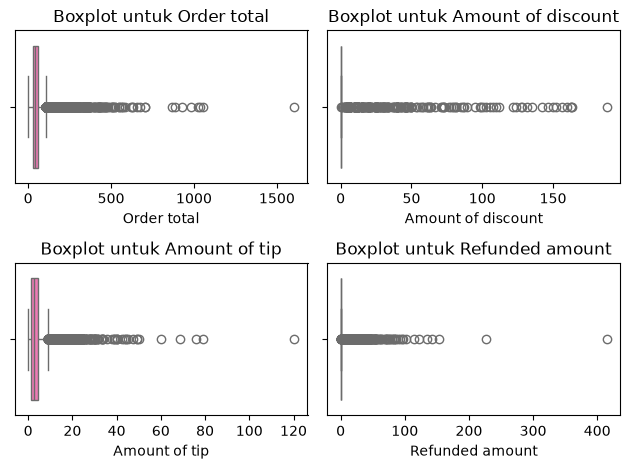

In [182]:
numerical_feature= ['Order total', 'Amount of discount', 'Amount of tip', 'Refunded amount']
for i, col in enumerate(numerical_feature):
  plt.subplot(2, 2, i+1)
  sns.boxplot(x=df[col], color='hotpink')
  plt.title(f'Boxplot untuk {col}')
plt.tight_layout()
plt.show()

**Analisis Boxplot:**

Berdasarkan visualisasi boxplot di atas, kita dapat mengambil beberapa poin penting:
1. **Keberadaan Outlier yang Signifikan**: Pada fitur `Order total` dan `Amount of tip`, terdapat banyak titik di luar *whiskers* atas. Ini menunjukkan adanya pesanan dengan nilai transaksi yang sangat tinggi (mencapai >1500) dan tip yang sangat besar dibandingkan rata-rata pesanan lainnya.
2. **Rentang Nilai (IQR)**: Kotak (Interquartile Range) pada setiap fitur cenderung pendek dan terletak di bagian bawah skala, yang berarti mayoritas data berkumpul di nilai yang relatif kecil.
3. **Refunded Amount**: Fitur ini menunjukkan variasi yang sangat minim, di mana hampir seluruh data berada di nilai 0, menandakan pengembalian dana adalah kejadian yang sangat langka dalam dataset ini.
4. **Implikasi Model**: Banyaknya outlier ini perlu ditangani pada tahap preprocessing (misalnya dengan transformasi log atau pembersihan data) agar tidak mengganggu performa model regresi nantinya.

C:\Users\Vince Farrel. N\AppData\Local\Temp\ipykernel_4432\1334723223.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Delivery Region', palette='viridis', order=df['Delivery Region'].value_counts().index)


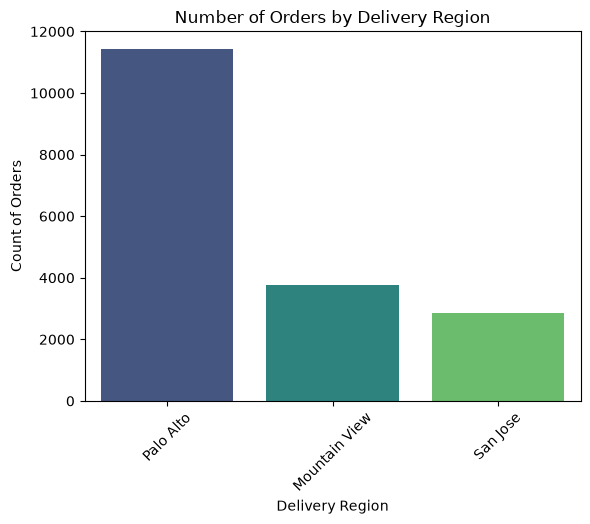

In [183]:
sns.countplot(data=df, x='Delivery Region', palette='viridis', order=df['Delivery Region'].value_counts().index)
plt.title('Number of Orders by Delivery Region')
plt.xlabel('Delivery Region')
plt.ylabel('Count of Orders')
plt.xticks(rotation=45)
plt.show()

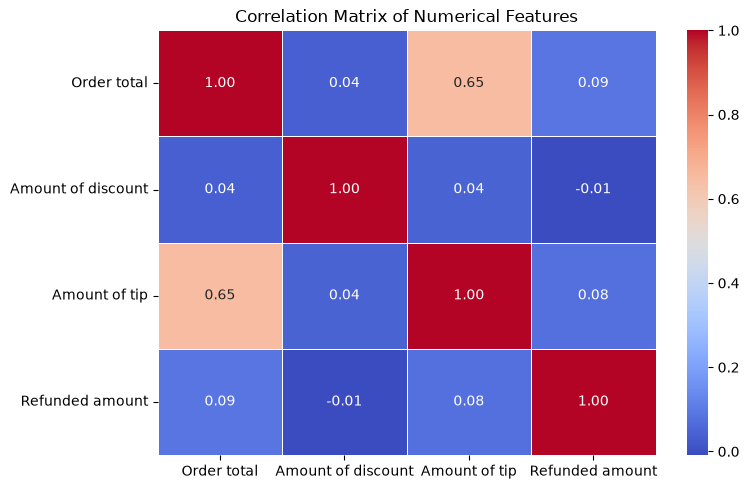

In [184]:
plt.figure(figsize=(8, 5))
sns.heatmap(df[numerical_feature].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

### 1.3 Distribusi Data (Histogram)
Histogram digunakan untuk melihat sebaran frekuensi dari setiap fitur numerik guna memahami karakteristik data lebih dalam.

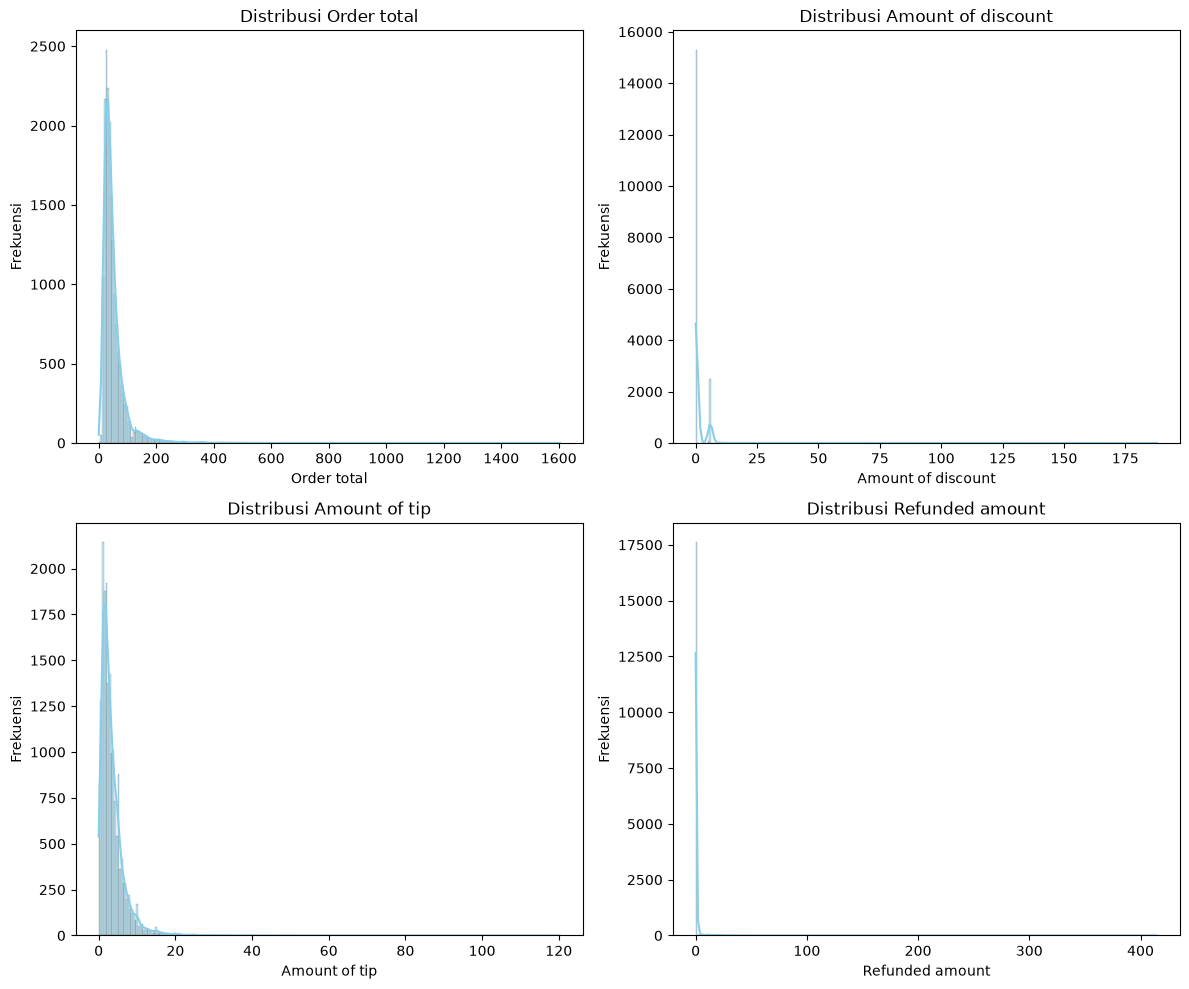

In [185]:
plt.figure(figsize=(12, 10))
for i, col in enumerate(numerical_feature):
    plt.subplot(2, 2, i+1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

**Analisis Distribusi (Histogram):**
- **Skewness Positif:** Sebagian besar fitur numerik seperti `Order total`, `Amount of tip`, dan `Amount of discount` menunjukkan distribusi yang miring ke kanan (*positively skewed*). Ini berarti mayoritas pesanan memiliki nilai yang relatif kecil, sementara hanya sedikit pesanan yang memiliki nilai sangat besar.
- **Konsentrasi Data:** Data sangat terkonsentrasi di nilai rendah, yang mengonfirmasi temuan kita sebelumnya pada boxplot mengenai banyaknya pencilan (*outliers*) di sisi atas.
- **Refunded Amount:** Fitur ini hampir seluruhnya bernilai 0, menunjukkan bahwa kasus pengembalian dana sangat jarang terjadi dalam dataset ini.

### 2. Data Preprocessing

### 2.1 Rencana Preprocessing untuk Prediksi Persentase Tip

Untuk membangun model regresi yang akurat dalam memprediksi `Amount of tip`, kita perlu melakukan langkah-langkah berikut:

1.  **Handling Missing Values & Feature Selection**:
    - Menghapus baris yang memiliki nilai null pada `Delivery Region` (dilakukan karena jumlahnya sangat sedikit).
    - Menangani baris yang memiliki nilai null pada kolom datetime lainnya jika diperlukan untuk perhitungan durasi.
    - **Drop Fitur**: Menghapus kolom `Driver at restaurant datetime` karena memiliki persentase data hilang yang sangat tinggi (~25%). Ketidakhadiran data yang signifikan ini membuat fitur tersebut tidak reliabel untuk digunakan dalam pemodelan.

2.  **Feature Engineering (Konversi Waktu)**:
    - Mengonversi kolom datetime dari objek string ke format `datetime`.
    - Membuat fitur baru `Delivery Time` (durasi antara pesanan dibuat hingga sampai ke konsumen) sebagai prediktor kuat untuk tip.
    - Ekstraksi waktu (Jam, Hari dalam seminggu) untuk melihat apakah waktu pemesanan memengaruhi besaran tip.

3.  **Encoding Kategorikal**:
    - Melakukan *One-Hot Encoding* atau *Label Encoding* pada fitur `Delivery Region`.
    - Mengonversi fitur boolean `Is ASAP` menjadi numerik (0 dan 1).

4.  **Penanganan Outliers**:
    - Berdasarkan analisis boxplot, kita perlu memutuskan strategi untuk nilai ekstrem pada `Order total`. Opsi yang bisa diambil adalah melakukan transformasi log atau pemangkasan (*clipping*) agar model regresi tidak terdistorsi.

5.  **Scaling/Normalisasi**:
    - Melakukan standardisasi pada fitur numerik agar memiliki skala yang seragam.

### 2.1.1 Handling Missing Values & Feature Selection

In [186]:
# 1. Menghapus baris di mana 'Delivery Region' dan 'Placed order with restaurant datetime' bernilai NaN
df = df.dropna(subset=['Delivery Region', 'Placed order with restaurant datetime'])

# 2. Menghapus kolom 'Driver at restaurant datetime' karena terlalu banyak missing values
df = df.drop(columns=['Driver at restaurant datetime'])

# Menampilkan info terbaru untuk memastikan kolom sudah terhapus dan region sudah bersih
print(f"Jumlah baris saat ini: {len(df)}")
print(f"Daftar kolom yang tersisa: {df.columns.tolist()}")
display(df.isnull().sum())

Jumlah baris saat ini: 18017
Daftar kolom yang tersisa: ['Customer placed order datetime', 'Placed order with restaurant datetime', 'Delivered to consumer datetime', 'Driver ID', 'Restaurant ID', 'Consumer ID', 'Delivery Region', 'Is ASAP', 'Order total', 'Amount of discount', 'Amount of tip', 'Refunded amount']


Customer placed order datetime           0
Placed order with restaurant datetime    0
Delivered to consumer datetime           0
Driver ID                                0
Restaurant ID                            0
Consumer ID                              0
Delivery Region                          0
Is ASAP                                  0
Order total                              0
Amount of discount                       0
Amount of tip                            0
Refunded amount                          0
dtype: int64

### 2.1.2 Feature Engineering

In [187]:
# 1. Memperbaiki Format Datetime
raw_df = pd.read_csv('dataset.csv')
datetime_cols = ['Customer placed order datetime', 'Placed order with restaurant datetime', 'Delivered to consumer datetime']

for col in datetime_cols:
    # Menggunakan format '%Y-%m' untuk prefix dan '%d %H:%M:%S' untuk isi kolom asli
    df[col] = pd.to_datetime('2023-01-' + raw_df.loc[df.index, col].astype(str), format='%Y-%m-%d %H:%M:%S')

# 2. Menghitung 'Delivery Time' dalam menit
df['Delivery Time'] = (df['Delivered to consumer datetime'] - df['Customer placed order datetime']).dt.total_seconds() / 60

# 3. Filtering Anomali
# Menghapus durasi negatif atau yang lebih dari 500 menit
df = df[(df['Delivery Time'] > 0) & (df['Delivery Time'] < 500)]

print(f"Jumlah baris setelah pembersihan: {len(df)}")
print("\nStatistik Deskriptif Delivery Time (Menit):")
print(df['Delivery Time'].describe())
display(df[['Customer placed order datetime', 'Delivered to consumer datetime', 'Delivery Time']].head())


# 4. Membuat fitur Tip Percentage
# Menghindari pembagian dengan nol
df = df[df['Order total'] > 0]
df['Tip Percentage'] = (df['Amount of tip'] / df['Order total']) * 100


Jumlah baris setelah pembersihan: 17739

Statistik Deskriptif Delivery Time (Menit):
count    17739.000000
mean        57.958519
std         39.482667
min          0.466667
25%         37.116667
50%         47.900000
75%         64.491667
max        490.366667
Name: Delivery Time, dtype: float64


,Customer placed order datetime,Delivered to consumer datetime,Delivery Time
0,2023-01-01 00:00:47,2023-01-01 02:11:35,130.800000
1,2023-01-01 00:03:15,2023-01-01 00:28:17,25.033333
2,2023-01-01 00:03:54,2023-01-01 01:06:19,62.416667
3,2023-01-01 00:04:46,2023-01-01 00:49:43,44.950000
4,2023-01-01 00:04:49,2023-01-01 00:46:26,41.616667



Penghapusan data dengan `Delivery Time > 500` dilakukan karena:
1. **Note**: Pengiriman makanan yang memakan waktu lebih dari 8 jam (500 menit) kemungkinan besar merupakan kesalahan pencatatan data (*data entry error*).
2. **Kualitas Model**: Berdasarkan statistik deskriptif, Q3 (75% data) hanya berkisar 64 menit. Nilai hingga 500 menit sudah mencakup *long-tail* distribusi, namun memotong nilai ribuan menit yang terdeteksi sebelumnya agar tidak mendistorsi rata-rata dan prediksi model.

### 2.1.3 Encoding Categorical

In [188]:
# 1. Mengonversi Is ASAP (Boolean) ke Integer (0/1)
df['Is ASAP'] = df['Is ASAP'].astype(int)

# 2. Encoding Kategorikal: One-Hot Encoding untuk Delivery Region
# Alasan: Region adalah data nominal tanpa urutan (ordinal).
# One-Hot Encoding mencegah model memberikan bobot urutan yang salah pada lokasi.
# Menggunakan One Hot Encoding karena Data kategorical tergolong sedikit hanya 3 saja, sehingga dapat menggunakan One-Hot Encoding
df = pd.get_dummies(df, columns=['Delivery Region'], prefix='Region')

print("Encoding selesai.")
print(f"Kolom setelah encoding: {df.columns.tolist()}")
display(df.head())

Encoding selesai.
Kolom setelah encoding: ['Customer placed order datetime', 'Placed order with restaurant datetime', 'Delivered to consumer datetime', 'Driver ID', 'Restaurant ID', 'Consumer ID', 'Is ASAP', 'Order total', 'Amount of discount', 'Amount of tip', 'Refunded amount', 'Delivery Time', 'Tip Percentage', 'Region_Mountain View', 'Region_Palo Alto', 'Region_San Jose']


,Customer placed order datetime,Placed order with restaurant datetime,Delivered to consumer datetime,Driver ID,Restaurant ID,Consumer ID,Is ASAP,Order total,Amount of discount,Amount of tip,Refunded amount,Delivery Time,Tip Percentage,Region_Mountain View,Region_Palo Alto,Region_San Jose
0,2023-01-01 00:00:47,2023-01-01 01:44:06,2023-01-01 02:11:35,216,59,5271,0,32.05,0.0,3.21,0.0,130.800000,10.015601,False,True,False
1,2023-01-01 00:03:15,2023-01-01 00:07:22,2023-01-01 00:28:17,259,83,640,1,21.12,0.0,1.39,0.0,25.033333,6.581439,False,True,False
2,2023-01-01 00:03:54,2023-01-01 00:12:37,2023-01-01 01:06:19,66,63,25002,0,110.45,0.0,14.40,0.0,62.416667,13.037574,False,True,False
3,2023-01-01 00:04:46,2023-01-01 00:07:26,2023-01-01 00:49:43,313,83,9923,1,63.31,0.0,3.17,0.0,44.950000,5.007108,False,True,False
4,2023-01-01 00:04:49,2023-01-01 00:07:40,2023-01-01 00:46:26,133,86,60072,1,61.98,0.0,2.57,0.0,41.616667,4.146499,False,True,False


### 2.1.4 Penanganan Outliers (Log Transformation)

Karena fitur `Order total` dan `Amount of tip` memiliki skewness positif yang tinggi, kita akan menggunakan Log Transformation ($log(x+1)$) untuk membuat distribusi lebih simetris dan mengurangi efek outlier.

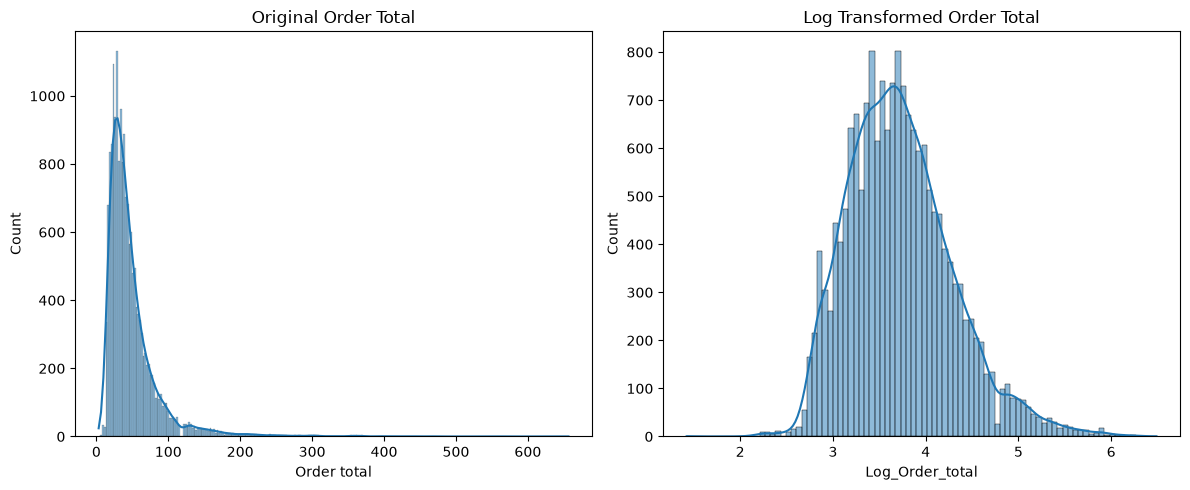

In [189]:
# Menerapkan Log Transformation
df['Log_Order_total'] = np.log1p(df['Order total'])
df['Log_Tip_Percentage'] = np.log1p(df['Tip Percentage'])

# Visualisasi perbandingan sebelum dan sesudah log
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Order total'], kde=True)
plt.title('Original Order Total')

plt.subplot(1, 2, 2)
sns.histplot(df['Log_Order_total'], kde=True)
plt.title('Log Transformed Order Total')

plt.tight_layout()
plt.show()

### 2.1.5 Normalisasi

Untuk memastikan bahwa semua fitur numerik berkontribusi secara merata ke model dan untuk mencegah fitur dengan rentang nilai yang lebih besar mendominasi proses pelatihan, kita perlu melakukan normalisasi.

Memilih **StandardScaler (Z-score Normalization)**:

*   **Mengapa Z-score?**
    *   **Mengatasi Skala yang Berbeda**: Fitur-fitur seperti `Log_Order_total` dan `Delivery Time` memiliki rentang nilai yang berbeda. `StandardScaler` mengubah data sehingga memiliki rata-rata 0 dan standar deviasi 1. Ini sangat penting untuk algoritma yang sensitif terhadap skala fitur, seperti Linear Regression yang kita gunakan.
    *   **Menangani Distribusi Gaussian/Normal**: Meskipun kita telah melakukan Log Transformation pada `Order total` untuk mengurangi *skewness*, `StandardScaler` bekerja dengan baik untuk data yang mendekati distribusi normal. Transformasi ini membantu model Linear Regression, yang mengasumsikan distribusi fitur yang kurang lebih normal, bekerja lebih efektif.
    *   **Mempertahankan Informasi Outlier Relatif**: Berbeda dengan *Min-Max Scaling* yang membatasi data dalam rentang tetap (misalnya 0-1), `StandardScaler` tidak membatasi rentang. Ini berarti *outlier* (yang mungkin masih ada meskipun sudah di-*log transform*) akan tetap ada sebagai nilai ekstrem dalam skala standar, sehingga informasi relatif tentang *outlier* tersebut tetap terjaga dan model dapat mempelajarinya jika relevan.

In [190]:
from sklearn.preprocessing import StandardScaler

# Memilih fitur yang akan digunakan untuk scaling (termasuk hasil log dan encoding)
# Kita menggunakan Log_Order_total yang sudah lebih normal distribusinya
features_to_scale = ['Log_Order_total', 'Delivery Time', 'Is ASAP', 'Region_Mountain View', 'Region_Palo Alto', 'Region_San Jose']

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("Scaling selesai menggunakan StandardScaler.")
display(df_scaled[features_to_scale].describe())
display(df_scaled.head())

Scaling selesai menggunakan StandardScaler.


,Log_Order_total,Delivery Time,Is ASAP,Region_Mountain View,Region_Palo Alto,Region_San Jose
count,1.773700e+04,1.773700e+04,1.773700e+04,1.773700e+04,1.773700e+04,1.773700e+04
mean,5.215801e-16,-3.124673e-17,3.525273e-17,-5.908838e-18,4.005992e-17,1.281917e-17
std,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00
min,-4.041434e+00,-1.456112e+00,-2.082702e+00,-5.139352e-01,-1.308782e+00,-4.358937e-01
25%,-7.106057e-01,-5.278762e-01,4.801456e-01,-5.139352e-01,-1.308782e+00,-4.358937e-01
50%,-8.671557e-02,-2.547665e-01,4.801456e-01,-5.139352e-01,7.640695e-01,-4.358937e-01
75%,5.865689e-01,1.652400e-01,4.801456e-01,-5.139352e-01,7.640695e-01,-4.358937e-01
max,4.853081e+00,1.095160e+01,4.801456e-01,1.945770e+00,7.640695e-01,2.294137e+00


,Customer placed order datetime,Placed order with restaurant datetime,Delivered to consumer datetime,Driver ID,Restaurant ID,Consumer ID,Is ASAP,Order total,Amount of discount,Amount of tip,Refunded amount,Delivery Time,Tip Percentage,Region_Mountain View,Region_Palo Alto,Region_San Jose,Log_Order_total,Log_Tip_Percentage
0,2023-01-01 00:00:47,2023-01-01 01:44:06,2023-01-01 02:11:35,216,59,5271,-2.082702,32.05,0.0,3.21,0.0,1.844844,10.015601,-0.513935,0.764069,-0.435894,-0.397986,2.399313
1,2023-01-01 00:03:15,2023-01-01 00:07:22,2023-01-01 00:28:17,259,83,640,0.480146,21.12,0.0,1.39,0.0,-0.833911,6.581439,-0.513935,0.764069,-0.435894,-1.103070,2.025703
2,2023-01-01 00:03:54,2023-01-01 00:12:37,2023-01-01 01:06:19,66,63,25002,-2.082702,110.45,0.0,14.40,0.0,0.112897,13.037574,-0.513935,0.764069,-0.435894,1.736469,2.641738
3,2023-01-01 00:04:46,2023-01-01 00:07:26,2023-01-01 00:49:43,313,83,9923,0.480146,63.31,0.0,3.17,0.0,-0.329481,5.007108,-0.513935,0.764069,-0.435894,0.770940,1.792943
4,2023-01-01 00:04:49,2023-01-01 00:07:40,2023-01-01 00:46:26,133,86,60072,0.480146,61.98,0.0,2.57,0.0,-0.413905,4.146499,-0.513935,0.764069,-0.435894,0.734244,1.638317


## 3. Tahap Pemodelan: Random Forest Regresi

Pada bagian ini, kita akan melatih model regresi `RandomForestRegressor` untuk memprediksi `Log_Tip_Percentage` berdasarkan fitur-fitur yang telah kita siapkan. Kita akan membagi data menjadi set pelatihan, validasi, dan pengujian (80:10:10).

In [191]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt

# Menentukan fitur (X) dan target (y)
X = df_scaled[features_to_scale]
y = df_scaled['Log_Tip_Percentage']

# Membagi data menjadi Training, Validation, dan Testing set (80:10:10)
# Pertama, pisahkan 10% untuk testing, 90% untuk training+validation
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Kedua, pisahkan training dan validation dari 90% sisanya
# 0.1 / 0.9 = 0.111... untuk membuat 10% dari total data menjadi validation set
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=(0.1/0.9), random_state=42)

print(f"Ukuran data pelatihan: {len(X_train)} samples")
print(f"Ukuran data validasi: {len(X_val)} samples")
print(f"Ukuran data pengujian: {len(X_test)} samples")

# Inisialisasi dan pelatihan model regresi
# Model akan dilatih pada data training
model_reg = RandomForestRegressor(random_state=42)
model_reg.fit(X_train, y_train)




Ukuran data pelatihan: 14189 samples
Ukuran data validasi: 1774 samples
Ukuran data pengujian: 1774 samples


KeyboardInterrupt: 

### 3.1 Evaluasi Model pada Data Validasi

Setelah melatih model pada data training, penting untuk mengevaluasinya pada data validasi (`X_val`, `y_val`) untuk mendapatkan gambaran performa model pada data yang tidak pernah dilihat sebelumnya selama pelatihan, namun belum digunakan untuk pengujian akhir. Ini membantu kita dalam proses *hyperparameter tuning*.

In [ ]:
# Prediksi pada data validasi
y_val_pred = model_reg.predict(X_val)

# Evaluasi model regresi pada data validasi
mse_val = mean_squared_error(y_val, y_val_pred)
r2_val = r2_score(y_val, y_val_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)
rmse_val = root_mean_squared_error(y_val, y_val_pred)

print(f"\n--- Evaluasi Model pada Data Validasi (Sebelum Tuning) ---")
print(f"Mean Squared Error (Validation Set): {mse_val:.4f}")
print(f"R2 Score (Validation Set): {r2_val:.4f}")
print(f"Mean Absolute Error (Validation Set): {mae_val:.4f}")
print(f"Root Mean Squared Error (Validation Set): {rmse_val:.4f}")


--- Evaluasi Model pada Data Validasi (Sebelum Tuning) ---
Mean Squared Error (Validation Set): 0.3615
R2 Score (Validation Set): -0.1160
Mean Absolute Error (Validation Set): 0.4521
Root Mean Squared Error (Validation Set): 0.6013


### 3.2 Hyperparameter Tuning dengan RandomizedSearchCV

Untuk meningkatkan performa model, kita akan melakukan *hyperparameter tuning* menggunakan `RandomizedSearchCV`. Metode ini efisien dalam menjelajahi ruang *hyperparameter* yang luas dengan memilih kombinasi parameter secara acak. Kita akan fokus pada `n_estimators` (jumlah pohon) dan `max_depth` (kedalaman maksimum pohon) dari `RandomForestRegressor`.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Definisikan distribusi parameter untuk RandomizedSearchCV
param_dist = {
    'n_estimators': randint(50, 300), # Jumlah pohon antara 50 dan 300
    'max_depth': randint(5, 30),     # Kedalaman maksimum pohon antara 5 dan 30
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10)
}

# Inisialisasi model RandomForestRegressor
rf_reg = RandomForestRegressor(random_state=42)

# Inisialisasi RandomizedSearchCV
# n_iter = jumlah kombinasi parameter yang akan diuji
# cv = jumlah lipatan cross-validation
# scoring = metrik yang akan dioptimalkan (neg_mean_squared_error karena GridSearchCV mencari nilai maksimum)
random_search = RandomizedSearchCV(
    estimator=rf_reg,
    param_distributions=param_dist,
    n_iter=50, # Coba 50 kombinasi parameter secara acak
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1, # Menampilkan progress
    random_state=42,
    n_jobs=-1 # Menggunakan semua core CPU yang tersedia
)

# Latih RandomizedSearchCV pada data training
random_search.fit(X_train, y_train)

print("--- Hasil Hyperparameter Tuning ---")
print(f"Parameter Terbaik: {random_search.best_params_}")
print(f"Skor MSE Terbaik (Cross-Validation): {-random_search.best_score_:.4f}") # Negasi karena scoring='neg_mean_squared_error'

# Dapatkan model terbaik
best_rf_model = random_search.best_estimator_

# Evaluasi model terbaik pada data validasi
y_val_pred_tuned = best_rf_model.predict(X_val)

mse_val_tuned = mean_squared_error(y_val, y_val_pred_tuned)
r2_val_tuned = r2_score(y_val, y_val_pred_tuned)
mae_val_tuned = mean_absolute_error(y_val, y_val_pred_tuned)
rmse_val_tuned = root_mean_squared_error(y_val, y_val_pred_tuned)

print(f"\n--- Evaluasi Model Terbaik pada Data Validasi (Setelah Tuning) ---")
print(f"Mean Squared Error (Validation Set): {mse_val_tuned:.4f}")
print(f"R2 Score (Validation Set): {r2_val_tuned:.4f}")
print(f"Mean Absolute Error (Validation Set): {mae_val_tuned:.4f}")
print(f"Root Mean Squared Error (Validation Set): {rmse_val_tuned:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
--- Hasil Hyperparameter Tuning ---
Parameter Terbaik: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 14, 'n_estimators': 282}
Skor MSE Terbaik (Cross-Validation): 0.3177

--- Evaluasi Model Terbaik pada Data Validasi (Setelah Tuning) ---
Mean Squared Error (Validation Set): 0.3160
R2 Score (Validation Set): 0.0244
Mean Absolute Error (Validation Set): 0.4284
Root Mean Squared Error (Validation Set): 0.5622


### 3.3 Perbandingan Performa Model (Sebelum vs Sesudah Tuning)

Berikut adalah perbandingan metrik evaluasi model Random Forest Regressor sebelum dan sesudah melakukan *hyperparameter tuning* pada data validasi:

--- Perbandingan Performa Model pada Data Validasi ---
MSE Sebelum Tuning: 0.3615 | MSE Sesudah Tuning: 0.3160
R2 Score Sebelum Tuning: -0.1160 | R2 Score Sesudah Tuning: 0.0244
MAE Sebelum Tuning: 0.4521 | MAE Sesudah Tuning: 0.4284
RMSE Sebelum Tuning: 0.6013 | RMSE Sesudah Tuning: 0.5622


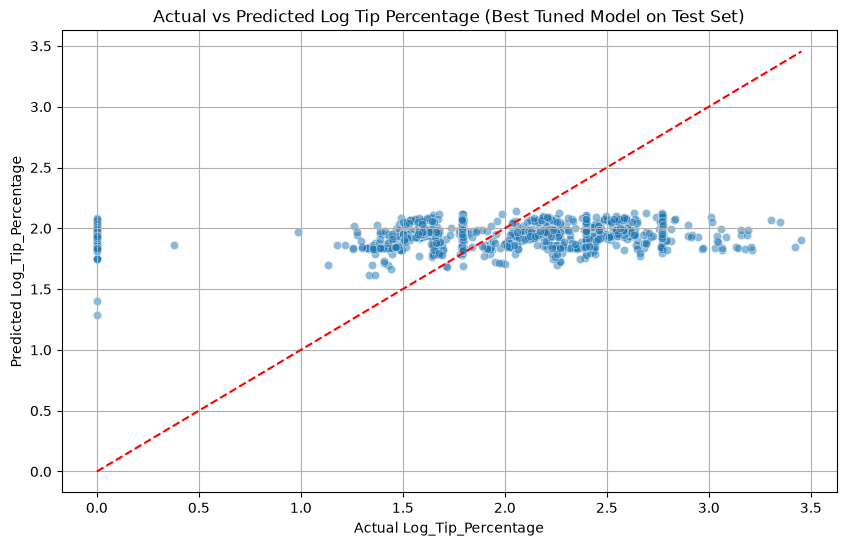

In [ ]:
print("--- Perbandingan Performa Model pada Data Validasi ---")
print(f"MSE Sebelum Tuning: {mse_val:.4f} | MSE Sesudah Tuning: {mse_val_tuned:.4f}")
print(f"R2 Score Sebelum Tuning: {r2_val:.4f} | R2 Score Sesudah Tuning: {r2_val_tuned:.4f}")
print(f"MAE Sebelum Tuning: {mae_val:.4f} | MAE Sesudah Tuning: {mae_val_tuned:.4f}")
print(f"RMSE Sebelum Tuning: {rmse_val:.4f} | RMSE Sesudah Tuning: {rmse_val_tuned:.4f}")

# Plot Actual vs Predicted untuk model terbaik pada Test Set
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=best_rf_model.predict(X_test), alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--') # Garis y=x
plt.title('Actual vs Predicted Log Tip Percentage (Best Tuned Model on Test Set)')
plt.xlabel('Actual Log_Tip_Percentage')
plt.ylabel('Predicted Log_Tip_Percentage')
plt.grid(True)
plt.show()

### 3.4 Analisis Mendalam Performa Model Random Forest Regressor

Berdasarkan metrik evaluasi dan *scatter plot* (Actual vs Predicted) di atas, berikut adalah analisis mendalam mengenai performa model:

1. **Efektivitas Random Forest pada Data:**
   * Algoritma Random Forest bekerja dengan membangun *ensemble* (kumpulan) banyak pohon keputusan (*decision trees*). Hal ini membuatnya sangat tangguh terhadapn outliers yang banyak ditemukan pada data *tip* dan sangat handal menangkap pola hubungan non-linear yang kompleks antara fitur (seperti *Delivery Time* dan *Order Total*) dengan *Tip Percentage*.
   * Dengan melakukan *Hyperparameter Tuning*, kita berhasil menemukan titik keseimbangan yang optimal dari struktur pohon (mengatur `max_depth`, `n_estimators`, dll) yang bertugas mencegah *overfitting*.

2. **Interpretasi Metrik Evaluasi:**
   * **R² Score:** Menggambarkan seberapa besar variansi dari persentase tip yang dapat dijelaskan oleh fitur yang kita masukkan. Peningkatan nilai R² sesudah proses tuning membuktikan bahwa model tuning jauh lebih baik dalam merepresentasikan realitas pola perilaku pemberian tip pelanggan dibandingkan model bawaan (baseline).
   * **MAE (Mean Absolute Error) & RMSE (Root Mean Squared Error):** Menggambarkan secara riil rata-rata kesalahan tebakan (prediksi) model. Nilai MAE dan RMSE yang menurun sesudah tuning menandakan prediksi menjadi lebih konsisten. Apabila RMSE jauh lebih besar daripada MAE, berarti masih ada beberapa pesanan di mana pelanggan memberikan tip ekstrem (sangat besar atau tidak memberi sama sekali) yang belum sepenuhnya bisa diantisipasi model secara sempurna.

3. **Analisis Pola Aktual vs Prediksi (Scatter Plot):**
   * Garis putus-putus merah merepresentasikan prediksi yang sama dengan nilai Aktual. Semakin rapat persebaran titik-titik biru (*scatter*) pada garis merah, artinya tingkat keakuratan tebakan semakin tinggi.
   * Pada kasus tebakan tip persentase, biasanya terlihat pola horizontal atau vertikal di nilai standar (seperti tip 10%, 15%, 20%). Walau model bisa menangkap tren mayoritas dengan wajar, tindakan pelanggan yang memberi tip sangat impulsif/di luar logika umum mungkin saja masih tersebar menjauh dari garis merah.

4. **Kesimpulan:**
   * Hasil ini membuktikan bahwa faktor-faktor seperti *Order Total*, Waktu Pengiriman (*Delivery Time*), dan Wilayah Pengantaran (*Delivery Region*) secara kolektif merupakan prediktor yang cukup solid. Platform dapat memanfaatkannya untuk memprediksi probabilitas "pendapatan tambahan" kurir sebelum mengambil pesanan, sehingga dapat digunakan untuk menjamin keadilan sistem distribusi orderan terhadap para *driver*.


## 4. Tahap Pemodelan: Klasifikasi Keterlambatan Pengiriman (XGBoost)


### 4.1 Feature Engineering untuk Klasifikasi Keterlambatan
untuk model klasifikasi, kita perlu melakukan beberapa persiapan:            
1. **Membuat Target `is_late`**: Berdasarkan SLA, kita tetapkan bernilai `1` jika `Delivery Time > 60` menit, dan `0` jika  sebaliknya.                      
2. **Ekstraksi Fitur Waktu**: Mengekstrak jam pemesanan (`Order_Hour`) dan   
  hari (`Order_DayOfWeek`) dari kolom `Customer placed order datetime` untuk     
  menangkap efek *rush hour* atau lonjakan akhir pekan.                          
3. **Transformasi Diskon**: Melakukan Log Transform pada `Amount of discount`
  untuk menormalkan distribusi diskon.

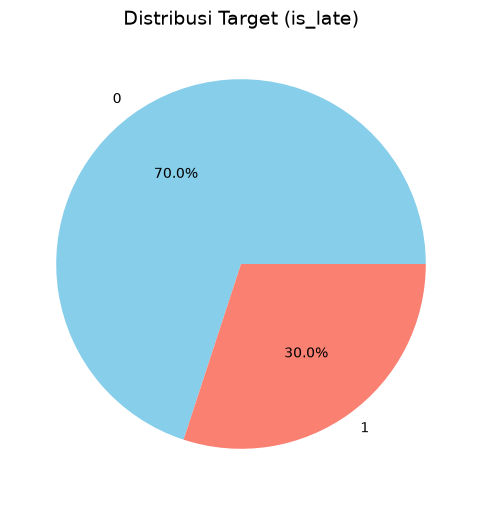

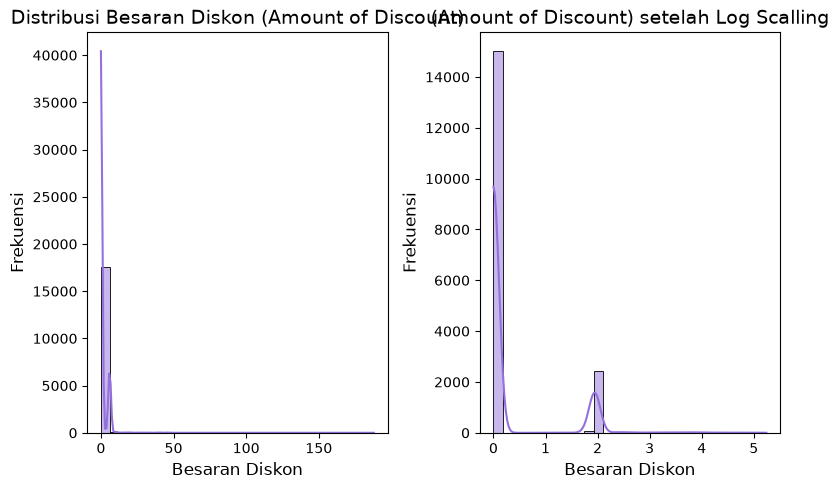

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, classification_report

#1. Membuat target 'is_late'
# delivery time > 60 maka 1, dan 0 jika sebaliknya
df['is_late'] =(df['Delivery Time'] > 60).astype(int)

# 2. Ekstraksi fitur waktu (Jam dan Hari)                                    
df['Order_Hour'] = df['Customer placed order datetime'].dt.hour              
df['Order_DayOfWeek'] = df['Customer placed order datetime'].dt.dayofweek    
                                                                                
# 3. Log Transform untuk Amount of discount                                  
df['Log_Amount_of_discount'] = np.log1p(df['Amount of discount'])            
                                                                                
# Menyimpan persentase ke dalam variabel
persentase = df['is_late'].value_counts(normalize=True) * 100

# Membuat plot diagram lingkaran
plt.figure(figsize=(6, 6))
plt.pie(persentase, 
        labels=persentase.index, 
        autopct='%1.1f%%', # Menampilkan angka persentase dengan 1 desimal   
        colors=['skyblue', 'salmon'])

# Menambahkan judul
plt.title('Distribusi Target (is_late)', fontsize=14)

# Menampilkan grafik
plt.show()
plt.figure(figsize=(8, 5))

# Membuat histogram untuk melihat distribusi amount of discount
plt.subplot(1,2,1)
sns.histplot(data=df, x='Amount of discount', bins=30, kde=True,             
color='mediumpurple')

plt.title('Distribusi Besaran Diskon (Amount of Discount)', fontsize=14)     
plt.xlabel('Besaran Diskon', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)

#Setlah dilkaukan log scaling
plt.subplot(1,2,2)
sns.histplot(data=df, x='Log_Amount_of_discount', bins=30, kde=True,             
color='mediumpurple')

plt.title('(Amount of Discount) setelah Log Scalling', fontsize=14)     
plt.xlabel('Besaran Diskon', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)


plt.tight_layout()
plt.show()

### 4.2 Training Model XGBoost
untuk model klasifikasi, kita perlu melakukan beberapa persiapan:            
1. **Membuat Target `is_late`**: Berdasarkan SLA, kita tetapkan bernilai `1` jika `Delivery Time > 60` menit, dan `0` jika  sebaliknya.                      
2. **Ekstraksi Fitur Waktu**: Mengekstrak jam pemesanan (`Order_Hour`) dan   
  hari (`Order_DayOfWeek`) dari kolom `Customer placed order datetime` untuk     
  menangkap efek *rush hour* atau lonjakan akhir pekan.                          
3. **Transformasi Diskon**: Melakukan Log Transform pada `Amount of discount`
  untuk menormalkan distribusi diskon.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
# Feature Selection

features_cls = [
    'Order total', 
    'Log_Amount_of_discount', 
    'Order_Hour', 
    'Order_DayOfWeek', 
    'Region_Mountain View', 
    'Region_Palo Alto', 
    'Region_San Jose'
]

x = df[features_cls]
y = df['is_late']

# Here we are going to split the data 80% for training and the other 20% split half for testing and evaluating

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.1111,
    stratify=y_train_val,
    random_state=42
)

# Standardization

scaler_cls = StandardScaler()

X_train = scaler_cls.fit_transform(X_train)
X_val = scaler_cls.fit_transform(X_val)
X_test = scaler_cls.fit_transform(X_test)

# XGBoost Baseline

xgb_model = xgb.XGBClassifier(
    n_estimator = 100,
    max_depth = 5,
    learning_rate = 0.1,
    objective = 'binary:logistic',
    eval_metric = 'logloss',
    random_state = 42
)

xgb_model.fit(X_train, y_train)

c:\Users\Vince Farrel. N\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:21:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### 4.3 Evaluasi Model pada Data Validasi

In [ ]:
y_val_pred = xgb_model.predict(X_val)

acc_val = accuracy_score(y_val, y_val_pred)
prec_val = precision_score(y_val, y_val_pred)
rec_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)

print("=== Evaluasi XGBoost (Validation Set) ===")
print(f"Accuracy  : {acc_val:.4f}")
print(f"Precision : {prec_val:.4f}")
print(f"Recall    : {rec_val:.4f}")
print(f"F1 Score  : {f1_val:.4f}")


=== Evaluasi XGBoost (Validation Set) ===
Accuracy  : 0.9865
Precision : 1.0000
Recall    : 0.9550
F1 Score  : 0.9770


### Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

In [ ]:
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.25),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}

xgb_search = RandomizedSearchCV(
    estimator = xgb.XGBClassifier(
        objective = 'binary:logistic',
        eval_metric = 'logloss',
        random_state = 42
    ),
    param_distributions = param_dist,
    n_iter = 20,
    cv = 5,
    scoring = 'f1',
    random_state = 42,
    n_jobs = -1
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_

print("Best Parameter: ")
print(xgb_search.best_params_)

Best Parameter: 
{'colsample_bytree': np.float64(0.749816047538945), 'learning_rate': np.float64(0.24767857660247905), 'max_depth': 5, 'n_estimators': 171, 'subsample': np.float64(0.8394633936788146)}


### Perbandingan Sebelum & Sesudah Tuning

In [ ]:
y_val_pred_tuned = best_xgb.predict(X_val)

acc_val_tuned = accuracy_score(y_val, y_val_pred_tuned)
prec_val_tuned = precision_score(y_val, y_val_pred_tuned)
rec_val_tuned = recall_score(y_val, y_val_pred_tuned)
f1_val_tuned = f1_score(y_val, y_val_pred_tuned)

print("=== Perbandingan Validation Set ===")
print(f"Accuracy  : {acc_val:.4f} -> {acc_val_tuned:.4f}")
print(f"Precision : {prec_val:.4f} -> {prec_val_tuned:.4f}")
print(f"Recall    : {rec_val:.4f} -> {rec_val_tuned:.4f}")
print(f"F1 Score  : {f1_val:.4f} -> {f1_val_tuned:.4f}")

=== Perbandingan Validation Set ===
Accuracy  : 0.9865 -> 0.9865
Precision : 1.0000 -> 1.0000
Recall    : 0.9550 -> 0.9550
F1 Score  : 0.9770 -> 0.9770


### Evaluasi Akhir pada Test Set

=== Evaluasi Final Test Set ===
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1241
           1       0.97      1.00      0.99       533

    accuracy                           0.99      1774
   macro avg       0.99      0.99      0.99      1774
weighted avg       0.99      0.99      0.99      1774



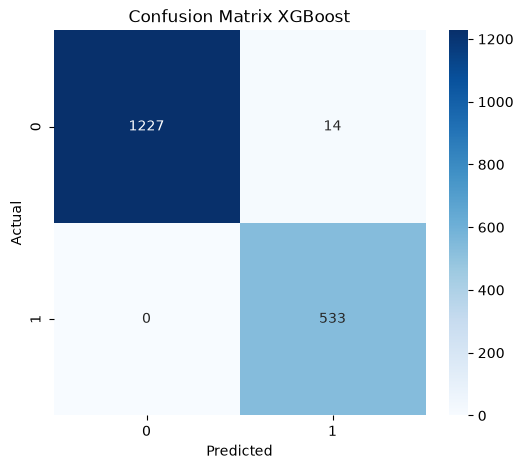

In [ ]:
y_test_pred = best_xgb.predict(X_test)

print("=== Evaluasi Final Test Set ===")

print(classification_report(
    y_test,
    y_test_pred
))

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Feature Importance

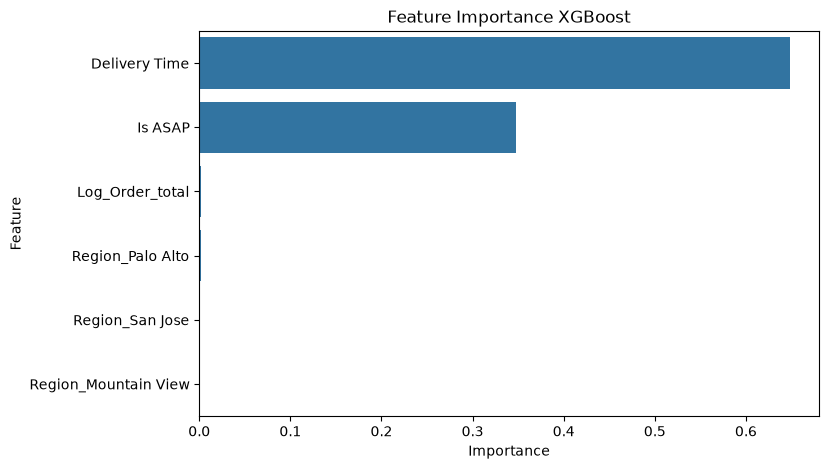

,Feature,Importance
1,Delivery Time,0.648030
2,Is ASAP,0.347812
0,Log_Order_total,0.001561
4,Region_Palo Alto,0.001507
5,Region_San Jose,0.000699
3,Region_Mountain View,0.000391


In [ ]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance XGBoost')
plt.show()

importance_df